<span style='color:red'>

# TITLE: `MOVIE GENRES DATA ANALYSIS PROJECT`

</span>

---
---
---

<span style='color:red'>

# 1. PROJECTS INTRODUCTION


---

<div style='background-color:darkgray; padding:15px;'>

<span style='color:blue'>
    
Hey Everyone!

Congratulations on making it to the projects!

**Projects are great for Resume Building and your Portfolio**. Projects help demonstrate that you know what you're doing. I recommend including these projects in your portfolio (*because I think they're pretty great!*)

Hope you enjoy them!

</div>

---

<span style='color:darkred'>
    
## Movie Genre Data Analysis

</span>

---

<div style='background-color:darkgray; padding:15px;'>

<span style='color:darkred'>
    
### Introduction

</span>

<span style='color:blue'>
    
We are going to focus highly on genres. I want to know everything about Genres.

Here are some things I want to look at

---

<span style='color:darkred'>
    
### Research Questions (Q):

</span>

1. Which genres are the most common (*number of movies made*)?

2. Which genres have high avg. budget and revenue?

3. Which genres have high avg. popularity?

4. Which genres have highest number of movies with an voting avg. >= 8?

---

<span style='color:darkred'>
    
### Research Hypotheses (H):

</span>

1. The best movie according to vote avg. return high profit and revenue.

2. The best movies acoording to popularity return high profit and revenue.

3. Highly budgeted movies return high revenue and profit.

4. Highly budgeted movies have a high popularity.

</div>

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('datasets/projects/imdb_movies.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  object 
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  object 
 6   cast                  10790 non-null  object 
 7   homepage              2936 non-null   object 
 8   director              10822 non-null  object 
 9   tagline               8042 non-null   object 
 10  keywords              9373 non-null   object 
 11  overview              10862 non-null  object 
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  object 
 14  production_companies  9836 non-null   object 
 15  release_date       

In [3]:
pd.set_option('display.max_columns', 22)

In [4]:
df.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,keywords,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,monster|dna|tyrannosaurus rex|velociraptor|island,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,future|chase|post-apocalyptic|dystopia|australia,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,based on novel|revolution|dystopia|sequel|dyst...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,android|spaceship|jedi|space opera|3d,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,car race|speed|revenge|suspense|car,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09


---
---

<span style='color:red'>

## 1.1 STEP NO. 1 - Check for Duplicates

---

In [5]:
# How many duplicates this DataFrame has?
df.duplicated().sum()

np.int64(1)

In [6]:
# Let's see the information that is duplicated...
df[df.duplicated()]

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,keywords,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
2090,42194,tt0411951,0.59643,30000000,967000,TEKKEN,Jon Foo|Kelly Overton|Cary-Hiroyuki Tagawa|Ian...,NaN,Dwight H. Little,Survival is no game,martial arts|dystopia|based on video game|mart...,"In the year of 2039, after World Wars destroy ...",92,Crime|Drama|Action|Thriller|Science Fiction,Namco|Light Song Films,3/20/10,110,5.0,2010,30000000.0,967000.0


In [7]:
# Now it's time to erase the duplicated row (row No. 2090)
df.drop_duplicates(inplace=True)

In [8]:
# I will check if I succesfully deleted the duplicated row
df[df.duplicated()]

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,keywords,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj


---
---

<span style='color:red'>

## 1.2 STEP NO. 2 - Check for NAN Values

---

In [9]:
# Let's see how many NAN Values each column has...
df.isna().sum()

id                         0
imdb_id                   10
popularity                 0
budget                     0
revenue                    0
original_title             0
cast                      76
homepage                7929
director                  44
tagline                 2824
keywords                1493
overview                   4
runtime                    0
genres                    23
production_companies    1030
release_date               0
vote_count                 0
vote_average               0
release_year               0
budget_adj                 0
revenue_adj                0
dtype: int64

In [10]:
# I will erase the "23 NAN Values" that the column "genres' has...
df.dropna(subset='genres', axis=0, inplace=True)

In [11]:
df.isna().sum()

id                         0
imdb_id                    8
popularity                 0
budget                     0
revenue                    0
original_title             0
cast                      75
homepage                7911
director                  42
tagline                 2806
keywords                1475
overview                   3
runtime                    0
genres                     0
production_companies    1016
release_date               0
vote_count                 0
vote_average               0
release_year               0
budget_adj                 0
revenue_adj                0
dtype: int64

---
---

<span style='color:red'>

## 1.3 STEP NO. 3 

---

   
   - Calculating Profit.
   
   - Reshaping the Original DataFrame (Selecting Relevant Data)


In [12]:
df = df.assign(profit=df['revenue'] - df['budget'])
df.head()

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,keywords,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj,profit
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,monster|dna|tyrannosaurus rex|velociraptor|island,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09,1363528810
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,future|chase|post-apocalyptic|dystopia|australia,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08,228436354
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,based on novel|revolution|dystopia|sequel|dyst...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08,185238201
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,android|spaceship|jedi|space opera|3d,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09,1868178225
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,car race|speed|revenge|suspense|car,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09,1316249360


In [13]:
# Since this DataFrame has some columns that are not relevant I will reshape it...
movies = df[['popularity', 'budget', 'revenue', 'original_title', 'runtime', 'genres', 'release_date', 'release_year',
             'vote_count', 'vote_average', 'profit']]
movies

,popularity,budget,revenue,original_title,runtime,genres,release_date,release_year,vote_count,vote_average,profit
0,32.985763,150000000,1513528810,Jurassic World,124,Action|Adventure|Science Fiction|Thriller,6/9/15,2015,5562,6.5,1363528810
1,28.419936,150000000,378436354,Mad Max: Fury Road,120,Action|Adventure|Science Fiction|Thriller,5/13/15,2015,6185,7.1,228436354
2,13.112507,110000000,295238201,Insurgent,119,Adventure|Science Fiction|Thriller,3/18/15,2015,2480,6.3,185238201
3,11.173104,200000000,2068178225,Star Wars: The Force Awakens,136,Action|Adventure|Science Fiction|Fantasy,12/15/15,2015,5292,7.5,1868178225
4,9.335014,190000000,1506249360,Furious 7,137,Action|Crime|Thriller,4/1/15,2015,2947,7.3,1316249360
...,...,...,...,...,...,...,...,...,...,...,...
10861,0.080598,0,0,The Endless Summer,95,Documentary,6/15/66,1966,11,7.4,0
10862,0.065543,0,0,Grand Prix,176,Action|Adventure|Drama,12/21/66,1966,20,5.7,0
10863,0.065141,0,0,Beregis Avtomobilya,94,Mystery|Comedy,1/1/66,1966,11,6.5,0
10864,0.064317,0,0,"What's Up, Tiger Lily?",80,Action|Comedy,11/2/66,1966,22,5.4,0


In [14]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10842 entries, 0 to 10865
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   popularity      10842 non-null  float64
 1   budget          10842 non-null  int64  
 2   revenue         10842 non-null  int64  
 3   original_title  10842 non-null  object 
 4   runtime         10842 non-null  int64  
 5   genres          10842 non-null  object 
 6   release_date    10842 non-null  object 
 7   release_year    10842 non-null  int64  
 8   vote_count      10842 non-null  int64  
 9   vote_average    10842 non-null  float64
 10  profit          10842 non-null  int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 1016.4+ KB


---
---

<span style='color:red'>

## 1.4 STEP NO. 4 - Split the Column 'GENRE'

---

In [15]:
# We need to import this, in order to let function the 'apply()' method this 'Series'
from pandas import Series, DataFrame

In [16]:
movies['genres'].str.split('|').apply(Series, 1).stack()

C:\Users\Milton Valle_Pro\AppData\Local\Temp\ipykernel_32872\272424905.py:1: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  movies['genres'].str.split('|').apply(Series, 1).stack()


0      0             Action
       1          Adventure
       2    Science Fiction
       3           Thriller
1      0             Action
                 ...       
10863  0            Mystery
       1             Comedy
10864  0             Action
       1             Comedy
10865  0             Horror
Length: 26955, dtype: object

---

In [17]:
movies['genres'].str.split('|', expand=True).stack()

0      0             Action
       1          Adventure
       2    Science Fiction
       3           Thriller
1      0             Action
                 ...       
10863  0            Mystery
       1             Comedy
10864  0             Action
       1             Comedy
10865  0             Horror
Length: 26955, dtype: object

In [18]:
# Otherwise I could alse use this line of code, that produces the same final result...
series_split = movies['genres'].str.split('|', expand=True).stack()
series_split

0      0             Action
       1          Adventure
       2    Science Fiction
       3           Thriller
1      0             Action
                 ...       
10863  0            Mystery
       1             Comedy
10864  0             Action
       1             Comedy
10865  0             Horror
Length: 26955, dtype: object

----

<span style='color:orange'>**Take a look to the following lines of code**

---

In [19]:
series_split.droplevel(1)

0                 Action
0              Adventure
0        Science Fiction
0               Thriller
1                 Action
              ...       
10863            Mystery
10863             Comedy
10864             Action
10864             Comedy
10865             Horror
Length: 26955, dtype: object

---

In [20]:
series_split = series_split.droplevel(1)
series_split

0                 Action
0              Adventure
0        Science Fiction
0               Thriller
1                 Action
              ...       
10863            Mystery
10863             Comedy
10864             Action
10864             Comedy
10865             Horror
Length: 26955, dtype: object

---

<span style='color:orange'>**We obtained the same earlier result**

---

In [21]:
series_split.name = 'genres_split'
series_split

0                 Action
0              Adventure
0        Science Fiction
0               Thriller
1                 Action
              ...       
10863            Mystery
10863             Comedy
10864             Action
10864             Comedy
10865             Horror
Name: genres_split, Length: 26955, dtype: object

In [22]:
# Now I will erase the column 'genres' because it's not useful anymore. 
del movies['genres']

# Then I introduce the new fixed column 'genres_split'
movies = movies.join(series_split)
movies

,popularity,budget,revenue,original_title,runtime,release_date,release_year,vote_count,vote_average,profit,genres_split
0,32.985763,150000000,1513528810,Jurassic World,124,6/9/15,2015,5562,6.5,1363528810,Action
0,32.985763,150000000,1513528810,Jurassic World,124,6/9/15,2015,5562,6.5,1363528810,Adventure
0,32.985763,150000000,1513528810,Jurassic World,124,6/9/15,2015,5562,6.5,1363528810,Science Fiction
0,32.985763,150000000,1513528810,Jurassic World,124,6/9/15,2015,5562,6.5,1363528810,Thriller
1,28.419936,150000000,378436354,Mad Max: Fury Road,120,5/13/15,2015,6185,7.1,228436354,Action
...,...,...,...,...,...,...,...,...,...,...,...
10863,0.065141,0,0,Beregis Avtomobilya,94,1/1/66,1966,11,6.5,0,Mystery
10863,0.065141,0,0,Beregis Avtomobilya,94,1/1/66,1966,11,6.5,0,Comedy
10864,0.064317,0,0,"What's Up, Tiger Lily?",80,11/2/66,1966,22,5.4,0,Action
10864,0.064317,0,0,"What's Up, Tiger Lily?",80,11/2/66,1966,22,5.4,0,Comedy


---
---

<span style='color:red'>

## Q.1. Which genres are the most common (*number of movies made*)?

---

In [23]:
# Way NO. 1 - Convert a Series into a DataFrame

movies.groupby('genres_split')['original_title'].nunique().sort_values(ascending=False).reset_index()

,genres_split,original_title
0,Drama,4672
1,Comedy,3750
2,Thriller,2841
3,Action,2339
4,Romance,1686
5,Horror,1580
6,Adventure,1442
7,Crime,1337
8,Family,1211
9,Science Fiction,1207


In [24]:
# Way No. 2 to convert the Series data into a DataFrame
pd.DataFrame(movies.groupby(by='genres_split').original_title.nunique()
            ).sort_values(by='original_title', ascending=False)

,original_title
genres_split,
Drama,4672
Comedy,3750
Thriller,2841
Action,2339
Romance,1686
Horror,1580
Adventure,1442
Crime,1337
Family,1211


In [25]:
genres_count = movies.groupby('genres_split')['original_title'].nunique().sort_values(ascending=False).reset_index()
genres_count

,genres_split,original_title
0,Drama,4672
1,Comedy,3750
2,Thriller,2841
3,Action,2339
4,Romance,1686
5,Horror,1580
6,Adventure,1442
7,Crime,1337
8,Family,1211
9,Science Fiction,1207


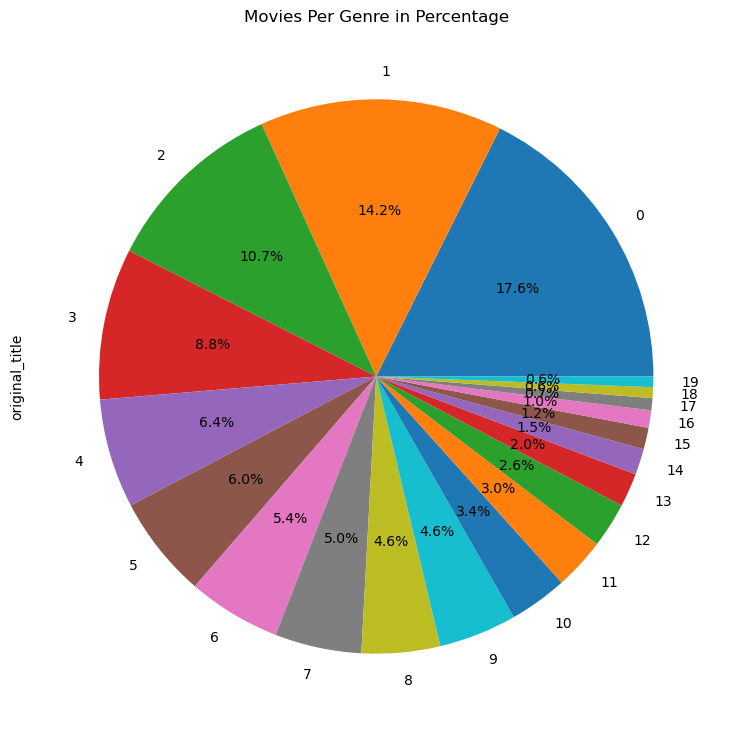

In [26]:
genres_count['original_title'].plot.pie(title='Movies Per Genre in Percentage', autopct='%1.1f%%',
                                       figsize=(12, 9))
plt.show()

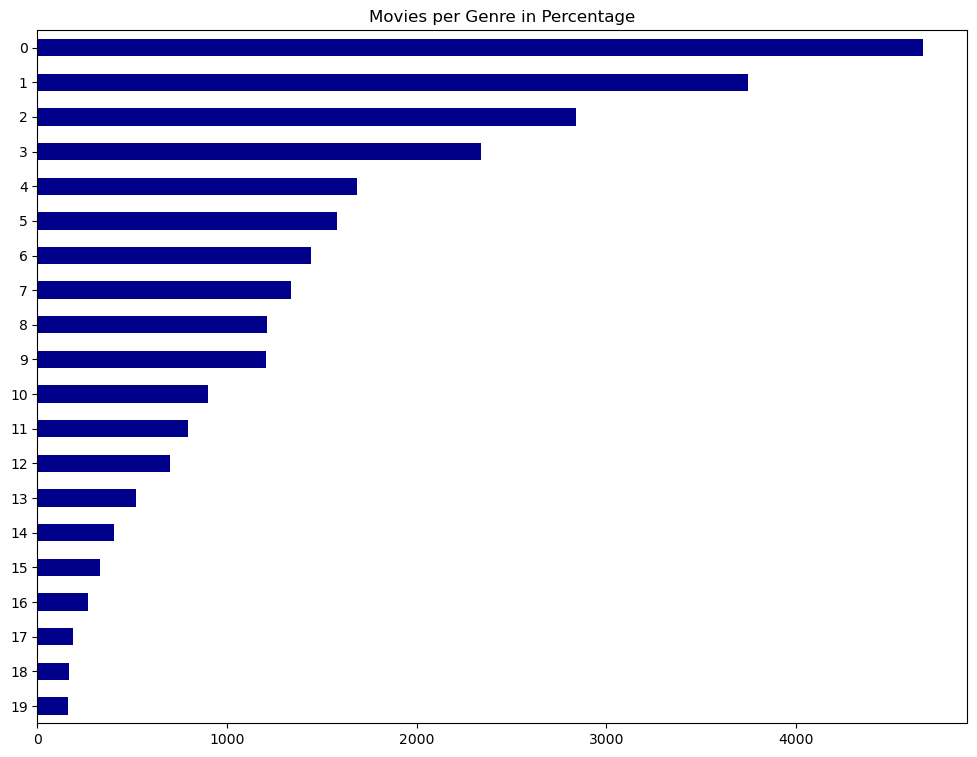

In [27]:
genres_count['original_title'][::-1].plot.barh(title='Movies per Genre in Percentage', color='DarkBlue', 
                                         figsize=(12, 9))
plt.show()

---
---

<span style='color:red'>

## Q.2. Which genres have high average budget and revenue?

---

<span style='color:orange'>**The following line of code is very relevant for configuring the DataFrame numeric columns with a certain number of decimals...**

---

In [28]:

pd.options.display.float_format = '{:.2f}'.format

---

In [29]:
#Teacher solution 
budget_avg = movies.groupby('genres_split').mean(numeric_only=True)
budget_avg.sort_values('budget', ascending=False, inplace=True)
budget_avg

,popularity,budget,revenue,runtime,release_year,vote_count,vote_average,profit
genres_split,,,,,,,,
Adventure,1.15,37543694.53,113137861.07,106.17,1999.39,513.13,5.94,75594166.54
Fantasy,0.99,32612585.35,96313657.08,100.74,2000.29,420.74,5.86,63701071.73
Action,0.93,27727820.33,72794732.00,104.92,2000.06,392.99,5.79,45066911.67
Science Fiction,1.00,24972680.52,70140558.03,99.42,1999.98,437.10,5.67,45167877.51
Family,0.79,23359337.42,72433176.37,89.60,2000.77,272.32,6.00,49073838.95
Animation,0.85,23159781.61,75256062.22,68.18,2004.00,303.00,6.40,52096280.62
War,0.73,20891886.10,47605183.30,127.63,1996.10,270.73,6.30,26713297.20
Western,0.59,18974107.98,28568709.28,117.58,1986.92,205.74,6.08,9594601.31
History,0.58,18594919.30,32011793.22,136.21,1997.50,183.77,6.41,13416873.91


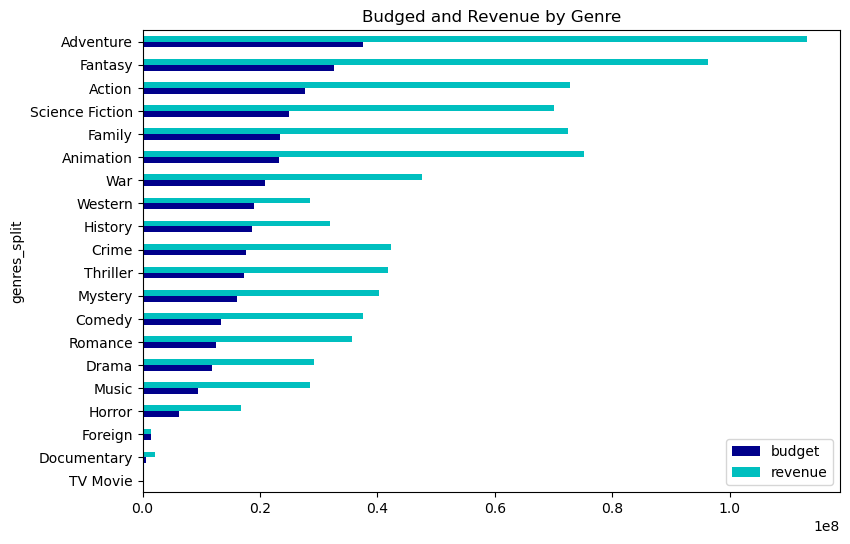

In [30]:
budget_avg[['budget', 'revenue']][::-1].plot.barh(title='Budged and Revenue by Genre', 
                                            color=('DarkBlue', 'c'), figsize=(9, 6));

In [31]:
revenue_avg = movies.groupby('genres_split').mean(numeric_only=True).sort_values('revenue', ascending=False)

revenue_avg['profit_percent'] = (revenue_avg['revenue']/revenue_avg['budget'])*100

revenue_avg.sort_values(by='profit_percent', ascending=False)

,popularity,budget,revenue,runtime,release_year,vote_count,vote_average,profit,profit_percent
genres_split,,,,,,,,,
Documentary,0.18,577149.15,2041106.99,102.65,2008.31,35.11,6.91,1463957.85,353.65
Animation,0.85,23159781.61,75256062.22,68.18,2004.00,303.00,6.40,52096280.62,324.94
Family,0.79,23359337.42,72433176.37,89.60,2000.77,272.32,6.00,49073838.95,310.08
Music,0.49,9438627.55,28571768.69,105.14,2000.20,124.34,6.48,19133141.14,302.71
Adventure,1.15,37543694.53,113137861.07,106.17,1999.39,513.13,5.94,75594166.54,301.35
Fantasy,0.99,32612585.35,96313657.08,100.74,2000.29,420.74,5.86,63701071.73,295.33
Romance,0.59,12531271.85,35691972.33,106.89,2000.44,166.07,6.04,23160700.48,284.82
Comedy,0.59,13297915.62,37526242.07,96.75,2000.82,176.44,5.91,24228326.45,282.20
Science Fiction,1.00,24972680.52,70140558.03,99.42,1999.98,437.10,5.67,45167877.51,280.87


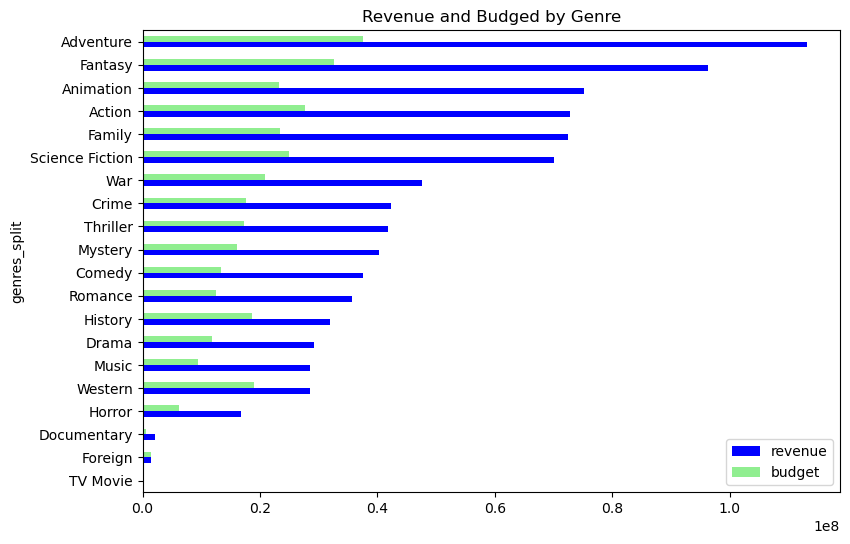

In [32]:
revenue_avg[['revenue', 'budget']][::-1].plot.barh(title='Revenue and Budged by Genre', 
                                             color=('blue', 'lightgreen'), figsize=(9, 6));

---
---

<span style='color:red'>

## Q.3. Which genres have high average profit?

---

In [33]:
profit_avg = movies.groupby('genres_split').mean(numeric_only=True).sort_values(by='profit', ascending=False)

profit_avg = profit_avg.assign(growing_factor = profit_avg['revenue']/profit_avg['budget'])
profit_avg

,popularity,budget,revenue,runtime,release_year,vote_count,vote_average,profit,growing_factor
genres_split,,,,,,,,,
Adventure,1.15,37543694.53,113137861.07,106.17,1999.39,513.13,5.94,75594166.54,3.01
Fantasy,0.99,32612585.35,96313657.08,100.74,2000.29,420.74,5.86,63701071.73,2.95
Animation,0.85,23159781.61,75256062.22,68.18,2004.00,303.00,6.40,52096280.62,3.25
Family,0.79,23359337.42,72433176.37,89.60,2000.77,272.32,6.00,49073838.95,3.10
Science Fiction,1.00,24972680.52,70140558.03,99.42,1999.98,437.10,5.67,45167877.51,2.81
Action,0.93,27727820.33,72794732.00,104.92,2000.06,392.99,5.79,45066911.67,2.63
War,0.73,20891886.10,47605183.30,127.63,1996.10,270.73,6.30,26713297.20,2.28
Crime,0.74,17663801.12,42368661.65,106.92,1999.49,278.81,6.12,24704860.52,2.40
Thriller,0.74,17207693.77,41728417.54,103.25,2001.69,255.48,5.75,24520723.77,2.42


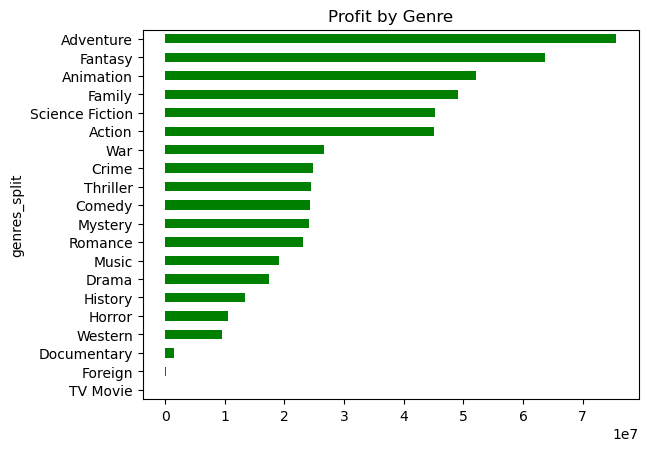

In [34]:
profit_avg['profit'][::-1].plot.barh(title='Profit by Genre', color='green');

---
---

<span style='color:red'>

## Q.4. Which genres have high average popularity?

---

In [35]:
popularity_avg = movies.groupby(['genres_split']).mean(
                        numeric_only=True).sort_values('popularity', ascending=False)
popularity_avg

,popularity,budget,revenue,runtime,release_year,vote_count,vote_average,profit
genres_split,,,,,,,,
Adventure,1.15,37543694.53,113137861.07,106.17,1999.39,513.13,5.94,75594166.54
Science Fiction,1.00,24972680.52,70140558.03,99.42,1999.98,437.10,5.67,45167877.51
Fantasy,0.99,32612585.35,96313657.08,100.74,2000.29,420.74,5.86,63701071.73
Action,0.93,27727820.33,72794732.00,104.92,2000.06,392.99,5.79,45066911.67
Animation,0.85,23159781.61,75256062.22,68.18,2004.00,303.00,6.40,52096280.62
Family,0.79,23359337.42,72433176.37,89.60,2000.77,272.32,6.00,49073838.95
Crime,0.74,17663801.12,42368661.65,106.92,1999.49,278.81,6.12,24704860.52
Thriller,0.74,17207693.77,41728417.54,103.25,2001.69,255.48,5.75,24520723.77
War,0.73,20891886.10,47605183.30,127.63,1996.10,270.73,6.30,26713297.20


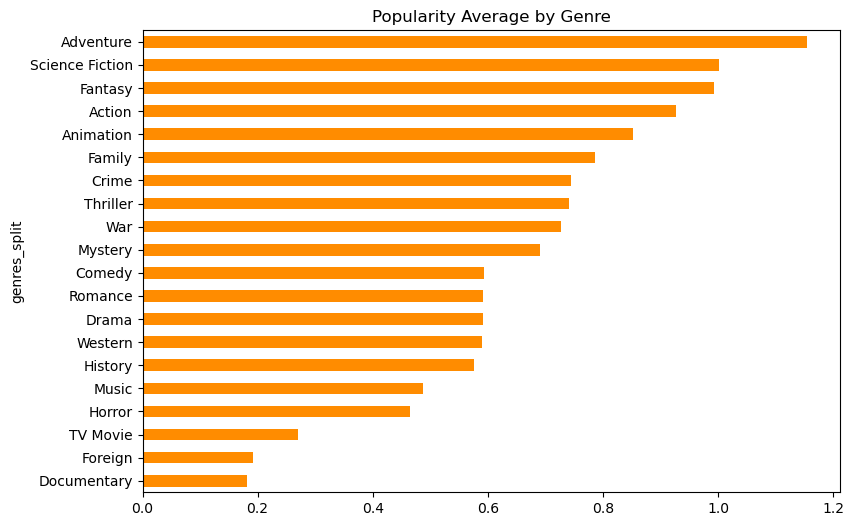

In [36]:
popularity_avg['popularity'][::-1].plot.barh(title='Popularity Average by Genre', color=('darkorange'), figsize=(9, 6));

In [37]:
movies['popularity'].describe()

count   26955.00
mean        0.71
std         1.11
min         0.00
25%         0.22
50%         0.41
75%         0.77
max        32.99
Name: popularity, dtype: float64

---
---

<span style='color:red'>

## Q.5. Which genres have highest number of movies with an voting avg >= 8?

---

In [38]:
movies

,popularity,budget,revenue,original_title,runtime,release_date,release_year,vote_count,vote_average,profit,genres_split
0,32.99,150000000,1513528810,Jurassic World,124,6/9/15,2015,5562,6.50,1363528810,Action
0,32.99,150000000,1513528810,Jurassic World,124,6/9/15,2015,5562,6.50,1363528810,Adventure
0,32.99,150000000,1513528810,Jurassic World,124,6/9/15,2015,5562,6.50,1363528810,Science Fiction
0,32.99,150000000,1513528810,Jurassic World,124,6/9/15,2015,5562,6.50,1363528810,Thriller
1,28.42,150000000,378436354,Mad Max: Fury Road,120,5/13/15,2015,6185,7.10,228436354,Action
...,...,...,...,...,...,...,...,...,...,...,...
10863,0.07,0,0,Beregis Avtomobilya,94,1/1/66,1966,11,6.50,0,Mystery
10863,0.07,0,0,Beregis Avtomobilya,94,1/1/66,1966,11,6.50,0,Comedy
10864,0.06,0,0,"What's Up, Tiger Lily?",80,11/2/66,1966,22,5.40,0,Action
10864,0.06,0,0,"What's Up, Tiger Lily?",80,11/2/66,1966,22,5.40,0,Comedy


In [39]:
voting_count_2 = movies[(movies['vote_count'] >= 50) & (movies['vote_average'] >= 8)]
voting_count_2

,popularity,budget,revenue,original_title,runtime,release_date,release_year,vote_count,vote_average,profit,genres_split
9,6.33,175000000,853708609,Inside Out,94,6/9/15,2015,3935,8.00,678708609,Comedy
9,6.33,175000000,853708609,Inside Out,94,6/9/15,2015,3935,8.00,678708609,Animation
9,6.33,175000000,853708609,Inside Out,94,6/9/15,2015,3935,8.00,678708609,Family
35,3.56,6000000,35401758,Room,117,10/16/15,2015,1520,8.00,29401758,Drama
35,3.56,6000000,35401758,Room,117,10/16/15,2015,1520,8.00,29401758,Thriller
...,...,...,...,...,...,...,...,...,...,...,...
10141,2.61,806948,32000000,Psycho,109,8/14/60,1960,1180,8.00,31193052,Horror
10141,2.61,806948,32000000,Psycho,109,8/14/60,1960,1180,8.00,31193052,Thriller
10222,2.38,22000000,321265768,Schindler's List,195,11/29/93,1993,2632,8.10,299265768,Drama
10222,2.38,22000000,321265768,Schindler's List,195,11/29/93,1993,2632,8.10,299265768,History


In [40]:
voting_count_1 = movies[movies['vote_average'] >= 8]
voting_count_1

,popularity,budget,revenue,original_title,runtime,release_date,release_year,vote_count,vote_average,profit,genres_split
9,6.33,175000000,853708609,Inside Out,94,6/9/15,2015,3935,8.00,678708609,Comedy
9,6.33,175000000,853708609,Inside Out,94,6/9/15,2015,3935,8.00,678708609,Animation
9,6.33,175000000,853708609,Inside Out,94,6/9/15,2015,3935,8.00,678708609,Family
35,3.56,6000000,35401758,Room,117,10/16/15,2015,1520,8.00,29401758,Drama
35,3.56,6000000,35401758,Room,117,10/16/15,2015,1520,8.00,29401758,Thriller
...,...,...,...,...,...,...,...,...,...,...,...
10222,2.38,22000000,321265768,Schindler's List,195,11/29/93,1993,2632,8.10,299265768,War
10575,0.20,0,0,MacskafogÃ³,96,10/2/86,1986,12,8.00,0,Animation
10575,0.20,0,0,MacskafogÃ³,96,10/2/86,1986,12,8.00,0,Family
10817,0.06,0,321952,The Last Waltz,117,5/1/78,1978,33,8.00,321952,Documentary


In [41]:
genres_vote2 = pd.DataFrame(voting_count_2.groupby(
    'genres_split').vote_average.nunique()).sort_values('vote_average', ascending=False)
genres_vote2

,vote_average
genres_split,
Drama,5
Documentary,5
Crime,4
Action,2
Adventure,2
Comedy,2
Thriller,2
Music,2
History,2


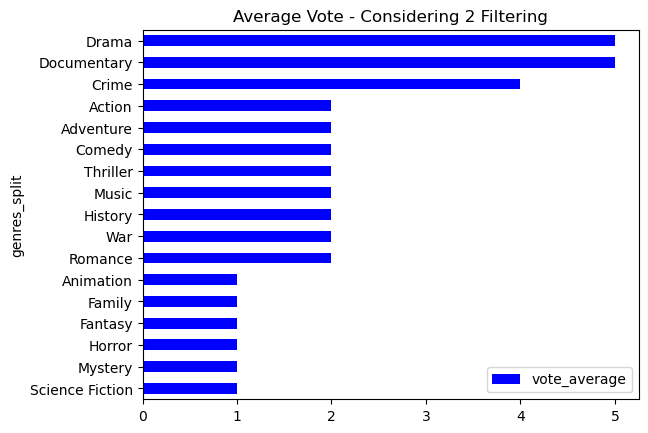

In [42]:
genres_vote2[::-1].plot.barh(title='Average Vote - Considering 2 Filtering', color=('blue'));

In [43]:
genres_vote1 = pd.DataFrame(voting_count_1.groupby(
    'genres_split').vote_average.nunique()).sort_values('vote_average', ascending=False)
genres_vote1

,vote_average
genres_split,
Documentary,9
Music,8
Drama,6
Comedy,5
Crime,4
Thriller,4
Animation,4
Science Fiction,3
Romance,3


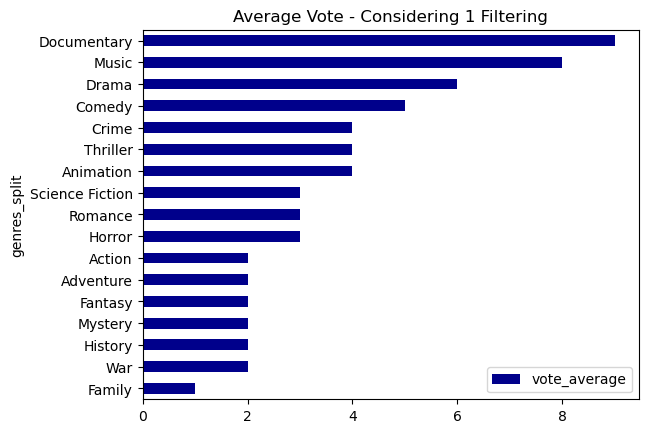

In [44]:
genres_vote1[::-1].plot.barh(title='Average Vote - Considering 1 Filtering', color=('darkblue'));

---
---

<span style='color:red'>

## H.1. The best movies according to `vote_average` return high profit and revenue?

---

In [45]:
# Since this DataFrame has some columns that are not relevant I will reshape it...
movies2 = df[['popularity', 'budget', 'revenue', 'original_title', 'runtime', 'genres', 'release_date', 
             'vote_count', 'vote_average', 'profit']]
movies2

,popularity,budget,revenue,original_title,runtime,genres,release_date,vote_count,vote_average,profit
0,32.99,150000000,1513528810,Jurassic World,124,Action|Adventure|Science Fiction|Thriller,6/9/15,5562,6.50,1363528810
1,28.42,150000000,378436354,Mad Max: Fury Road,120,Action|Adventure|Science Fiction|Thriller,5/13/15,6185,7.10,228436354
2,13.11,110000000,295238201,Insurgent,119,Adventure|Science Fiction|Thriller,3/18/15,2480,6.30,185238201
3,11.17,200000000,2068178225,Star Wars: The Force Awakens,136,Action|Adventure|Science Fiction|Fantasy,12/15/15,5292,7.50,1868178225
4,9.34,190000000,1506249360,Furious 7,137,Action|Crime|Thriller,4/1/15,2947,7.30,1316249360
...,...,...,...,...,...,...,...,...,...,...
10861,0.08,0,0,The Endless Summer,95,Documentary,6/15/66,11,7.40,0
10862,0.07,0,0,Grand Prix,176,Action|Adventure|Drama,12/21/66,20,5.70,0
10863,0.07,0,0,Beregis Avtomobilya,94,Mystery|Comedy,1/1/66,11,6.50,0
10864,0.06,0,0,"What's Up, Tiger Lily?",80,Action|Comedy,11/2/66,22,5.40,0


In [46]:
movies2_counted = movies2[movies2['vote_count'] >= 50]
movies2_counted

,popularity,budget,revenue,original_title,runtime,genres,release_date,vote_count,vote_average,profit
0,32.99,150000000,1513528810,Jurassic World,124,Action|Adventure|Science Fiction|Thriller,6/9/15,5562,6.50,1363528810
1,28.42,150000000,378436354,Mad Max: Fury Road,120,Action|Adventure|Science Fiction|Thriller,5/13/15,6185,7.10,228436354
2,13.11,110000000,295238201,Insurgent,119,Adventure|Science Fiction|Thriller,3/18/15,2480,6.30,185238201
3,11.17,200000000,2068178225,Star Wars: The Force Awakens,136,Action|Adventure|Science Fiction|Fantasy,12/15/15,5292,7.50,1868178225
4,9.34,190000000,1506249360,Furious 7,137,Action|Crime|Thriller,4/1/15,2947,7.30,1316249360
...,...,...,...,...,...,...,...,...,...,...
10821,0.93,0,0,Fahrenheit 451,112,Drama|Science Fiction,9/6/66,93,6.80,0
10822,0.67,7500000,33736689,Who's Afraid of Virginia Woolf?,131,Drama,6/21/66,74,7.50,26236689
10825,0.51,0,0,Blow-Up,111,Drama|Mystery|Thriller,12/18/66,103,6.80,0
10827,0.41,1377800,0,Batman,105,Family|Adventure|Comedy|Science Fiction|Crime,7/30/66,99,5.90,-1377800


In [47]:
movie_corr = movies2_counted.corr(method='spearman', numeric_only=True)
movie_corr

,popularity,budget,revenue,runtime,vote_count,vote_average,profit
popularity,1.00,0.48,0.59,0.23,0.77,0.19,0.50
budget,0.48,1.00,0.71,0.36,0.55,-0.04,0.33
revenue,0.59,0.71,1.00,0.34,0.68,0.11,0.84
runtime,0.23,0.36,0.34,1.00,0.26,0.29,0.21
vote_count,0.77,0.55,0.68,0.26,1.00,0.29,0.58
vote_average,0.19,-0.04,0.11,0.29,0.29,1.00,0.20
profit,0.50,0.33,0.84,0.21,0.58,0.20,1.00


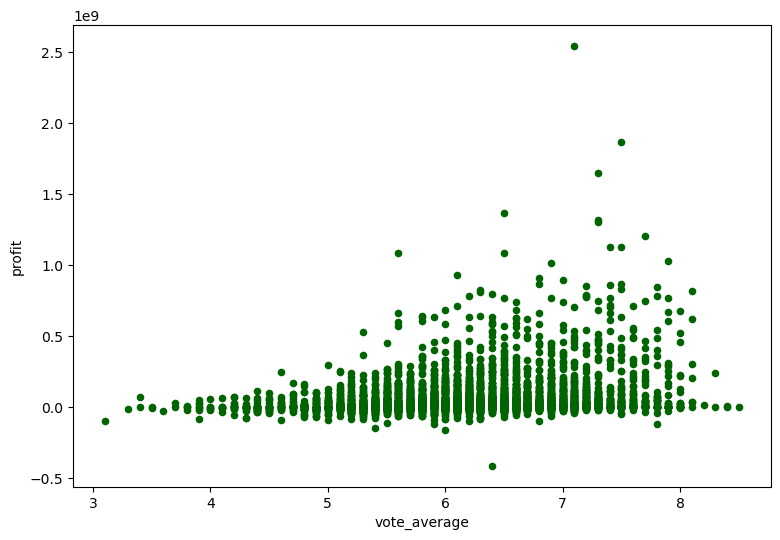

In [48]:
movies2_counted.plot.scatter(x='vote_average', y='profit', figsize=(9, 6), color='darkgreen');

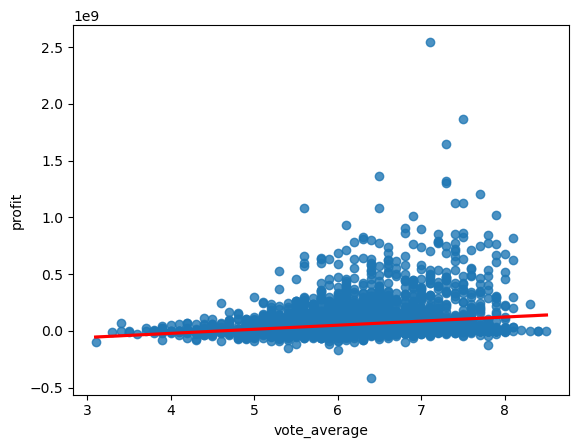

In [49]:
sns.regplot(x='vote_average', y='profit', data=movies2_counted, line_kws={'color':'red'});

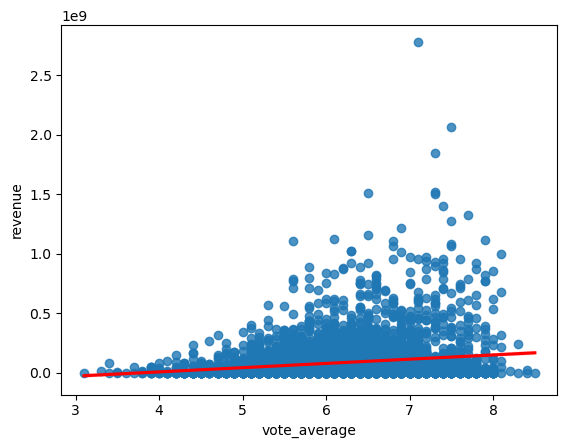

In [50]:
sns.regplot(x='vote_average', y='revenue', data=movies2_counted, line_kws={'color':'red'});

---

<span style='color:green'>
    
**Yes, both (`profit` and `revenue`) return higher profit and revenue, based on `vote_average`**

---

---
---

<span style='color:red'>

## H.2. The best movies according to `popularity` return high profit and revenue?

---

In [51]:
movie_corr

,popularity,budget,revenue,runtime,vote_count,vote_average,profit
popularity,1.00,0.48,0.59,0.23,0.77,0.19,0.50
budget,0.48,1.00,0.71,0.36,0.55,-0.04,0.33
revenue,0.59,0.71,1.00,0.34,0.68,0.11,0.84
runtime,0.23,0.36,0.34,1.00,0.26,0.29,0.21
vote_count,0.77,0.55,0.68,0.26,1.00,0.29,0.58
vote_average,0.19,-0.04,0.11,0.29,0.29,1.00,0.20
profit,0.50,0.33,0.84,0.21,0.58,0.20,1.00


<Axes: xlabel='popularity', ylabel='profit'>

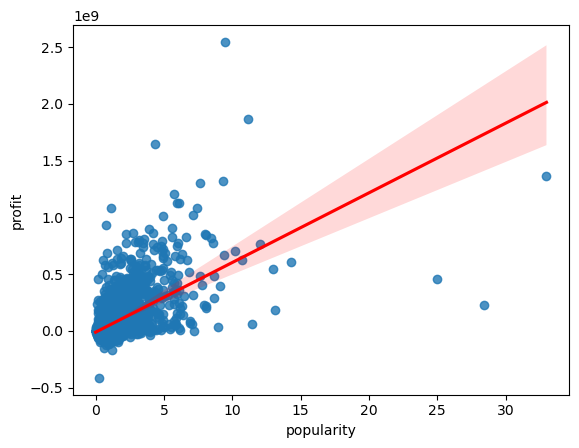

In [52]:
sns.regplot(data = movies2_counted, x='popularity', y='profit', line_kws={'color':'red'})


<Axes: xlabel='popularity', ylabel='revenue'>

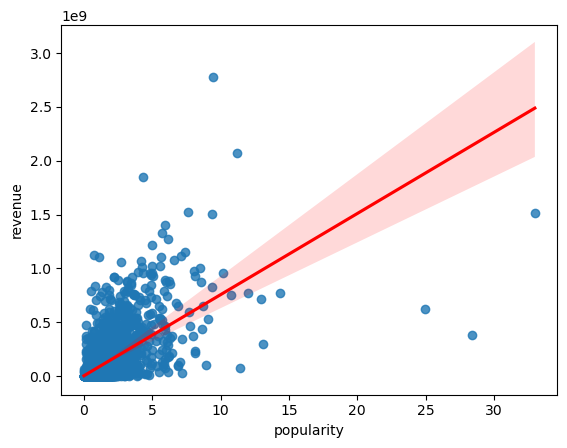

In [53]:
sns.regplot(data = movies2_counted, x='popularity', y='revenue', line_kws={'color':'red'})


---

<span style='color:green'>
    
**Yes, both (`profit` and `revenue`) return higher profit and revenue based on `popularity`**

---

---
---

<span style='color:red'>

## H.3. Highly budgeted movies return high `revenue` and `profit`.

---

In [54]:
movies2_counted.head()

,popularity,budget,revenue,original_title,runtime,genres,release_date,vote_count,vote_average,profit
0,32.99,150000000,1513528810,Jurassic World,124,Action|Adventure|Science Fiction|Thriller,6/9/15,5562,6.50,1363528810
1,28.42,150000000,378436354,Mad Max: Fury Road,120,Action|Adventure|Science Fiction|Thriller,5/13/15,6185,7.10,228436354
2,13.11,110000000,295238201,Insurgent,119,Adventure|Science Fiction|Thriller,3/18/15,2480,6.30,185238201
3,11.17,200000000,2068178225,Star Wars: The Force Awakens,136,Action|Adventure|Science Fiction|Fantasy,12/15/15,5292,7.50,1868178225
4,9.34,190000000,1506249360,Furious 7,137,Action|Crime|Thriller,4/1/15,2947,7.30,1316249360


<Axes: xlabel='budget', ylabel='profit'>

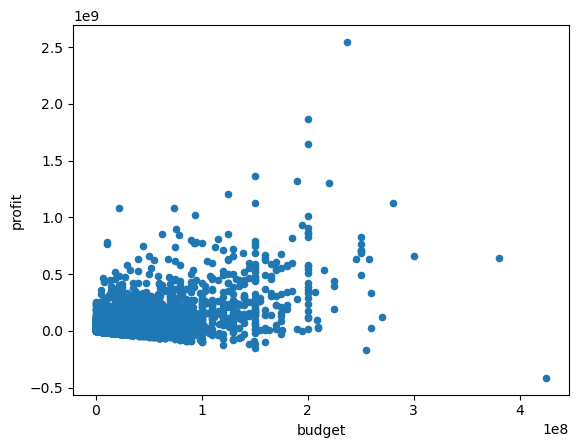

In [55]:
movies2_counted.plot.scatter(x='budget', y='profit')

<Axes: xlabel='budget', ylabel='profit'>

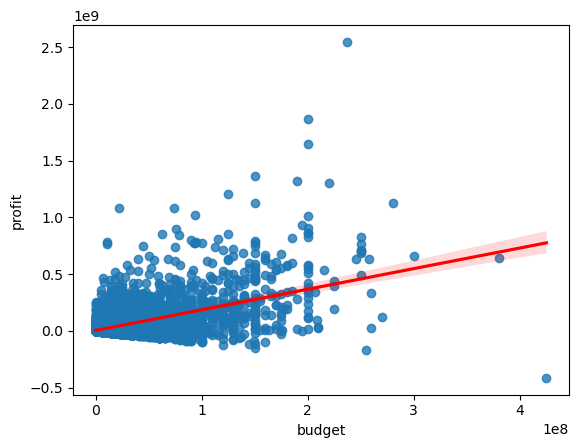

In [56]:
sns.regplot(data=movies2_counted, x='budget', y='profit', line_kws={'color':'red'})

<Axes: xlabel='budget', ylabel='revenue'>

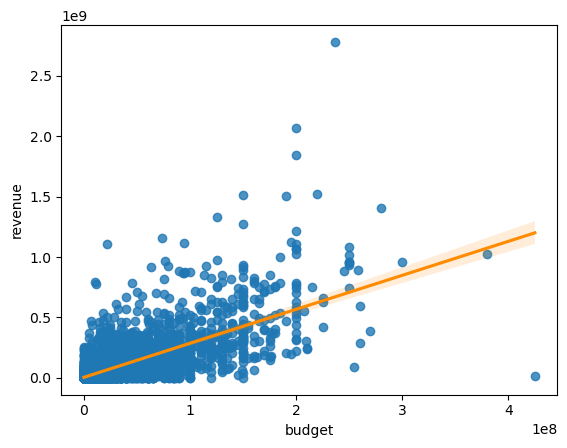

In [57]:
sns.regplot(data=movies2_counted, x='budget', y='revenue', line_kws={'color':'darkorange'})

---

<span style='color:green'>
    
**Yes, both Highly Budgeted movies, return higher profit and revenue based on `revenue` and `profit`**

---

---
---

<span style='color:red'>

## H.4. Highly budgeted movies have a high `popularity`.

---

<Axes: xlabel='budget', ylabel='popularity'>

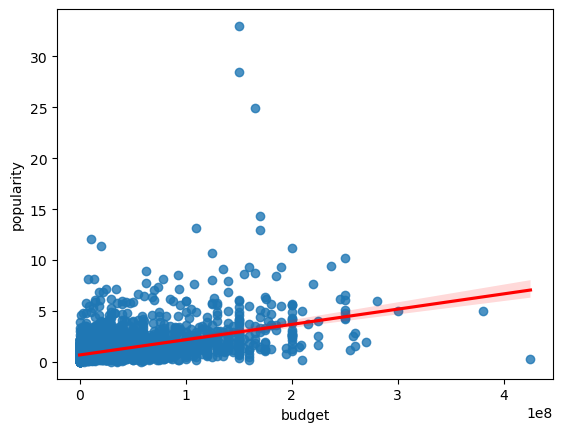

In [58]:
sns.regplot(data=movies2_counted, x='budget', y='popularity', line_kws={'color':'red'})

---

<span style='color:green'>
    
**Yes, both Highly Budgeted movies, return higher profit and revenue based on `revenue` and `profit`**

---

---
---

In [59]:
movies

,popularity,budget,revenue,original_title,runtime,release_date,release_year,vote_count,vote_average,profit,genres_split
0,32.99,150000000,1513528810,Jurassic World,124,6/9/15,2015,5562,6.50,1363528810,Action
0,32.99,150000000,1513528810,Jurassic World,124,6/9/15,2015,5562,6.50,1363528810,Adventure
0,32.99,150000000,1513528810,Jurassic World,124,6/9/15,2015,5562,6.50,1363528810,Science Fiction
0,32.99,150000000,1513528810,Jurassic World,124,6/9/15,2015,5562,6.50,1363528810,Thriller
1,28.42,150000000,378436354,Mad Max: Fury Road,120,5/13/15,2015,6185,7.10,228436354,Action
...,...,...,...,...,...,...,...,...,...,...,...
10863,0.07,0,0,Beregis Avtomobilya,94,1/1/66,1966,11,6.50,0,Mystery
10863,0.07,0,0,Beregis Avtomobilya,94,1/1/66,1966,11,6.50,0,Comedy
10864,0.06,0,0,"What's Up, Tiger Lily?",80,11/2/66,1966,22,5.40,0,Action
10864,0.06,0,0,"What's Up, Tiger Lily?",80,11/2/66,1966,22,5.40,0,Comedy


---
---

<span style='color:red'>

## H.5. Look at the Profit per Genre per Year.

---

In [60]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26955 entries, 0 to 10865
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   popularity      26955 non-null  float64
 1   budget          26955 non-null  int64  
 2   revenue         26955 non-null  int64  
 3   original_title  26955 non-null  object 
 4   runtime         26955 non-null  int64  
 5   release_date    26955 non-null  object 
 6   release_year    26955 non-null  int64  
 7   vote_count      26955 non-null  int64  
 8   vote_average    26955 non-null  float64
 9   profit          26955 non-null  int64  
 10  genres_split    26955 non-null  object 
dtypes: float64(2), int64(6), object(3)
memory usage: 2.5+ MB


In [61]:
time_genere1 = pd.DataFrame(movies.groupby(['release_year', 'genres_split'])['profit'].mean())
time_genere1

profit
release_year genres_split               
1960         Action           6363125.00
             Adventure         431000.00
             Comedy           5258750.00
             Crime                  0.00
             Drama            8245619.38
...                                  ...
2015         Science Fiction 83321303.52
             TV Movie         -150000.00
             Thriller        32869106.85
             War             54677314.33
             Western         72856619.00

[1049 rows x 1 columns]

In [62]:
final_genre = pd.pivot_table(time_genere1, values='profit', index=['genres_split'], columns=['release_year'])
final_genre

release_year,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
genres_split,,,,,,,,,,,,,,,,,,,,,,,
Action,6363125.00,2457142.86,10437500.00,14999691.25,24280000.00,16104504.78,324785.71,21732786.43,8868478.83,5861449.30,7735913.45,...,32379154.19,38048623.21,45977444.05,47642764.40,57555510.74,34571030.36,51968078.25,71910257.42,47431725.63,69943650.02,90399046.75
Adventure,431000.00,39130002.33,21214285.71,9428395.00,24123400.00,25124276.33,791563.64,49281873.86,15122159.40,16651809.40,11406377.67,...,70756754.32,64895200.09,83916731.08,55016526.81,113364919.74,98125646.68,113343224.56,162549574.30,100638113.40,120373306.99,144787868.97
Animation,NaN,211880014.00,NaN,0.00,0.00,0.00,-105000.00,100921706.00,0.00,0.00,25837628.50,...,40307312.15,39047734.97,67147670.53,51907242.58,48862898.25,58455658.64,63420098.93,69231546.88,93718795.26,64313463.25,83691174.38
Comedy,5258750.00,22198001.40,1599974.80,765591.92,7080111.38,3264285.71,-149550.00,10135087.47,-1277777.78,-125000.00,11901488.58,...,22147617.44,24944308.17,30674848.55,21483012.43,24741982.81,23154807.88,27241358.72,25631999.14,25068455.09,26648786.86,33703819.07
Crime,0.00,18828411.00,3709948.67,369526.75,1723307.30,-22500.00,-275560.00,12899678.71,6762174.60,31482963.00,-2125000.00,...,15680793.69,21551432.96,16700048.40,31258696.85,11016642.31,13490412.32,25395271.62,29522925.56,23248589.51,5903014.23,61286524.37
Documentary,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,NaN,NaN,0.00,...,316012.71,6772940.00,5229344.63,321262.23,-1603933.56,187417.77,2567196.82,1102306.59,321880.23,13104.14,531061.86
Drama,8245619.38,4912698.38,4373796.19,1587307.69,3726105.55,11933809.80,1014793.06,18045095.00,6354859.15,10317995.54,19753262.84,...,17180823.51,12994800.14,13953425.42,16736384.02,15209056.89,13510589.18,10830976.52,23418944.87,13344942.61,13697098.67,16315310.44
Family,3333333.33,42576002.80,4000000.00,-333333.33,37818181.75,51671428.67,-341828.57,64281204.00,-640000.00,0.00,17225085.67,...,51714774.93,35281751.28,80470561.73,44483026.14,62009322.10,98999767.49,65483435.47,69321493.02,89321956.44,56295182.74,85974520.75
Fantasy,-375000.00,0.00,-126.00,-500000.00,24068181.75,NaN,0.00,-3000000.00,-2000000.00,0.00,0.00,...,64388182.00,57967661.44,93461583.43,51441997.77,96235822.10,83235328.52,94486677.85,122245621.97,79363628.00,112966482.64,86576948.30


In [63]:
time_genre2 = pd.DataFrame(movies.groupby(['release_year', 'genres_split'])['profit'].mean()).unstack(level=0)
time_genre2

profit                                                   \
release_year          1960         1961        1962        1963        1964   
genres_split                                                                  
Action          6363125.00   2457142.86 10437500.00 14999691.25 24280000.00   
Adventure        431000.00  39130002.33 21214285.71  9428395.00 24123400.00   
Animation              NaN 211880014.00         NaN        0.00        0.00   
Comedy          5258750.00  22198001.40  1599974.80   765591.92  7080111.38   
Crime                 0.00  18828411.00  3709948.67   369526.75  1723307.30   
Documentary            NaN          NaN         NaN         NaN         NaN   
Drama           8245619.38   4912698.38  4373796.19  1587307.69  3726105.55   
Family          3333333.33  42576002.80  4000000.00  -333333.33 37818181.75   
Fantasy         -375000.00         0.00     -126.00  -500000.00 24068181.75   
Foreign               0.00         0.00     -126.00        0.00        0.00   
History         9600000.00   2333333.33 11250000.00  4908750.00        0.00   
Horror          4389007.43    600000.00   231600.00   898558.78   -10833.33   
Music                 0.00  18828411.00  8000000.00         NaN 30354655.20   
Mystery                NaN         0.00  -245000.00  1568014.67  1216209.75   
Romance         5225000.00    214285.71  -400025.20  4388698.50  6722222.22   
Science Fiction -316666.67         0.00   -31000.00  -375000.00  -300000.00   
TV Movie               NaN          NaN         NaN         NaN         NaN   
Thriller        5028842.00          NaN  7902857.14  8612335.30 14029426.56   
War                   0.00  11450000.00 15000000.00  1000000.00  2546757.33   
Western          484166.67   -566666.67 13266666.67        0.00        0.00   

                                                                             \
release_year           1965       1966         1967        1968        1969   
genres_split                                                                  
Action          16104504.78  324785.71  21732786.43  8868478.83  5861449.30   
Adventure       25124276.33  791563.64  49281873.86 15122159.40 16651809.40   
Animation              0.00 -105000.00 100921706.00        0.00        0.00   
Comedy           3264285.71 -149550.00  10135087.47 -1277777.78  -125000.00   
Crime             -22500.00 -275560.00  12899678.71  6762174.60 31482963.00   
Documentary             NaN       0.00         0.00         NaN         NaN   
Drama           11933809.80 1014793.06  18045095.00  6354859.15 10317995.54   
Family          51671428.67 -341828.57  64281204.00  -640000.00        0.00   
Fantasy                 NaN       0.00  -3000000.00 -2000000.00        0.00   
Foreign                0.00       0.00          NaN         NaN         NaN   
History         -3440000.00       0.00          NaN  4433333.33 28102963.00   
Horror            -60000.00   -6333.33    -16250.00  7520356.50  -175000.00   
Music           76757143.00        NaN   7200000.00  2266666.67        0.00   
Mystery                0.00 1550000.00   8459992.67 25626555.75 -4000000.00   
Romance         50547239.20 1216666.67  17960342.64  5444314.00  -312500.00   
Science Fiction        0.00  917866.67    -16250.00 18043865.75        0.00   
TV Movie               0.00        NaN          NaN         NaN        0.00   
Thriller        11285049.36  650000.00  26892953.00  6762174.60 23658164.33   
War             11020224.38 2000000.00  20300000.00  4325000.00 -4000000.00   
Western          -950000.00  181714.29   3000000.00  5000000.00 14993349.00   

                              ...                                       \
release_year            1970  ...        2005         2006        2007   
genres_split                  ...                                        
Action            7735913.45  ... 32379154.19  38048623.21 45977444.05   
Adventure        11406377.67  ... 70756754.32  64895200.09 83916731.08   
Animation     

<Axes: xlabel='None-release_year', ylabel='genres_split'>

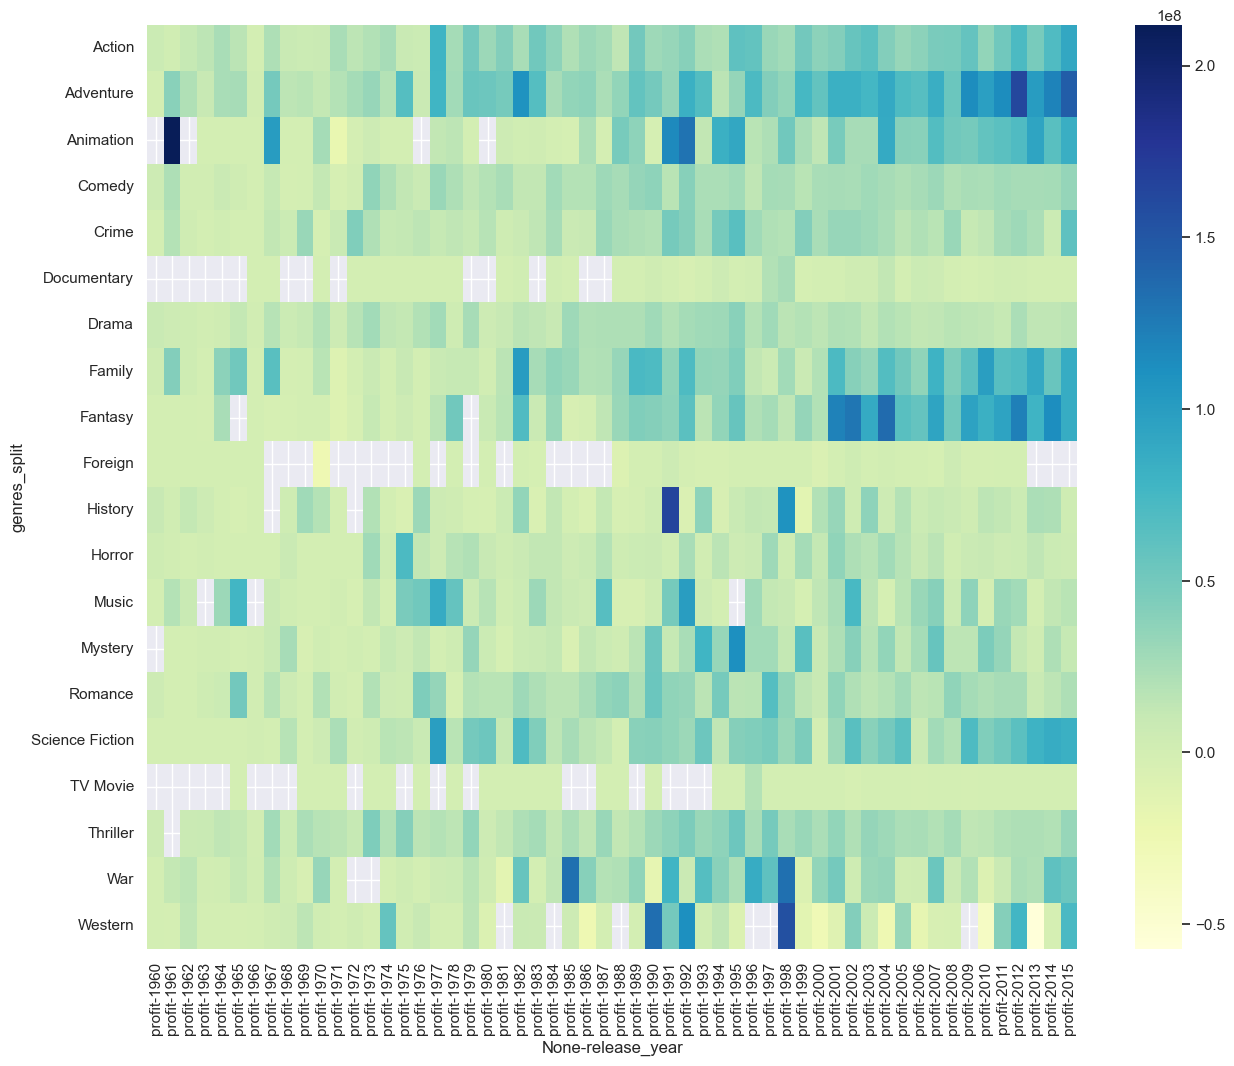

In [64]:
sns.set(rc={'figure.figsize':(15, 12)})
sns.heatmap(time_genre2, cmap='YlGnBu')

Text(0.5, 1.0, 'Genres by Profit per Year')

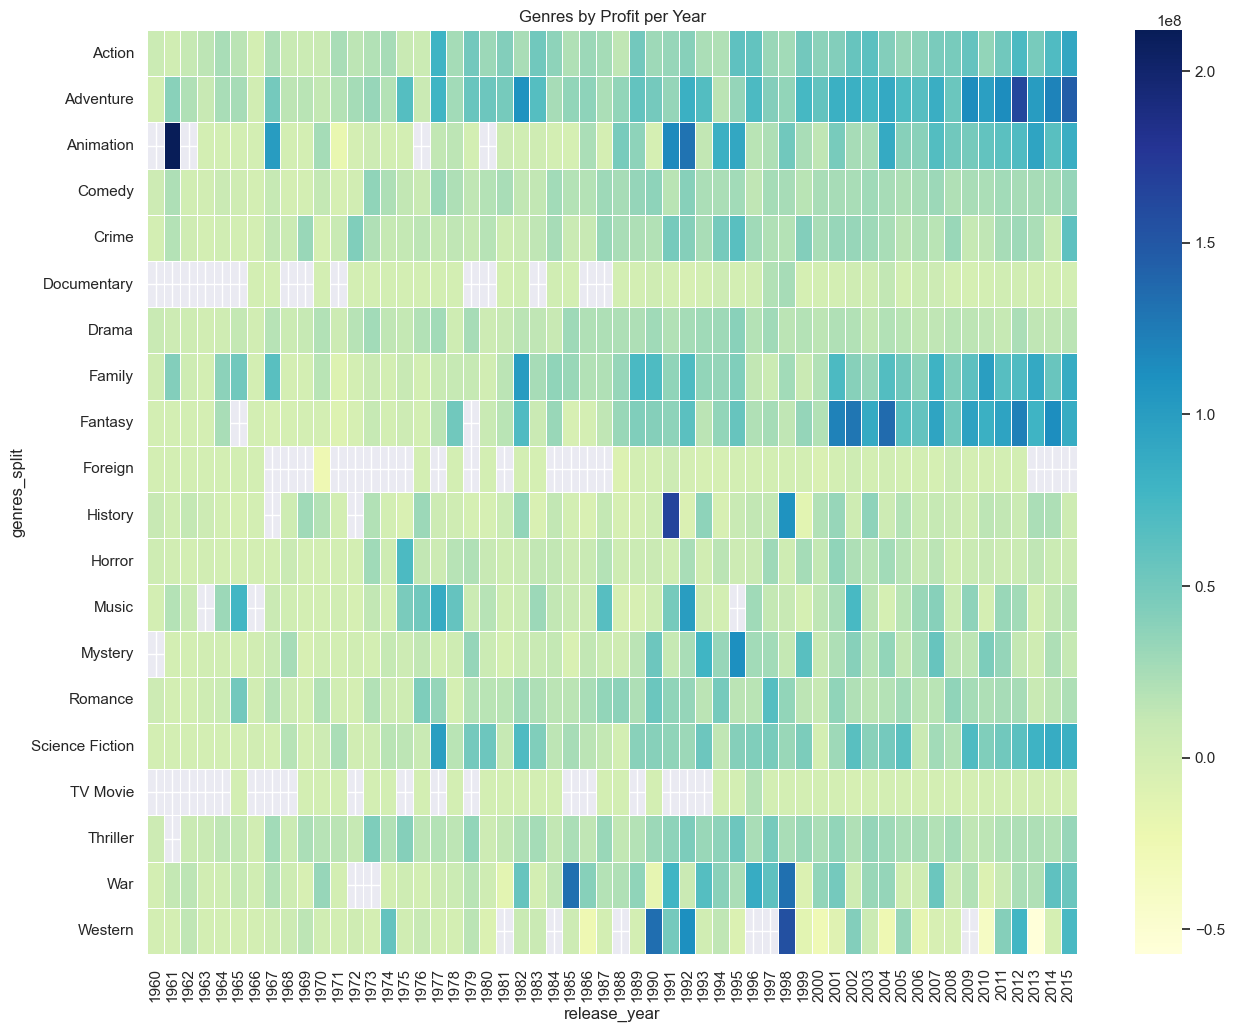

In [65]:
sns.set(rc={'figure.figsize':(15, 12)})
sns.heatmap(final_genre, cmap='YlGnBu', linewidths=0.5)
plt.title('Genres by Profit per Year')